<a href="https://colab.research.google.com/github/palak-singh1181/Palak-First/blob/main/Week6_Autoencoder_Denoising.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPooling2D, UpSampling2D
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")
print("TensorFlow version:", tf.__version__)

Libraries imported successfully!
TensorFlow version: 2.20.0


In [2]:
# Load MNIST dataset
(X_train, _), (X_test, _) = tf.keras.datasets.mnist.load_data()

# Normalize 0 to 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Reshape to (samples, 28, 28, 1)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("Dataset loaded successfully!")
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Dataset loaded successfully!
Train shape: (60000, 28, 28, 1)
Test shape: (10000, 28, 28, 1)


Noise added successfully!


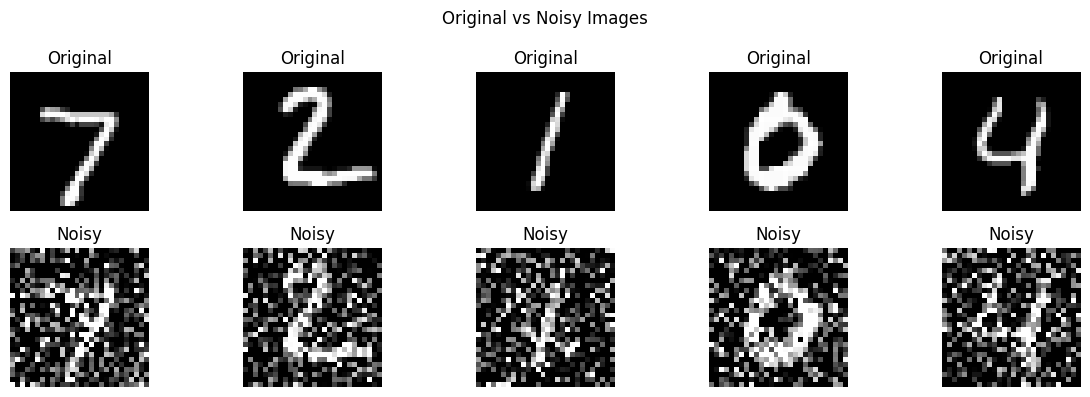

In [3]:
# Add noise to images
noise_factor = 0.5

X_train_noisy = X_train + noise_factor * np.random.normal(
                            loc=0.0, scale=1.0, size=X_train.shape)
X_test_noisy = X_test + noise_factor * np.random.normal(
                            loc=0.0, scale=1.0, size=X_test.shape)

# Clip values between 0 and 1
X_train_noisy = np.clip(X_train_noisy, 0., 1.)
X_test_noisy = np.clip(X_test_noisy, 0., 1.)

print("Noise added successfully!")

# Visualize original vs noisy
plt.figure(figsize=(12, 4))
for i in range(5):
    # Original
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Noisy
    plt.subplot(2, 5, i+6)
    plt.imshow(X_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

plt.suptitle("Original vs Noisy Images")
plt.tight_layout()
plt.show()

In [4]:
# Build Autoencoder Model
input_img = Input(shape=(28, 28, 1))

# Encoder
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)

# Decoder
x = Conv2D(16, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# Model
autoencoder = Model(input_img, decoded)

# Compile
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Summary
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Train Autoencoder
print("Training Autoencoder...")

history = autoencoder.fit(
    X_train_noisy, X_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(X_test_noisy, X_test),
    verbose=1
)

print("\nTraining Complete!")

Training Autoencoder...
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 0.1842 - val_loss: 0.1231
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1190 - val_loss: 0.1132
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1119 - val_loss: 0.1083
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1083 - val_loss: 0.1061
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1062 - val_loss: 0.1043
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1046 - val_loss: 0.1029
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1035 - val_loss: 0.1024
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.1026 - val_loss: 0.1016
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1020 - val_loss: 0.1008
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.1014 - val_loss: 0.1002

Training Complete!


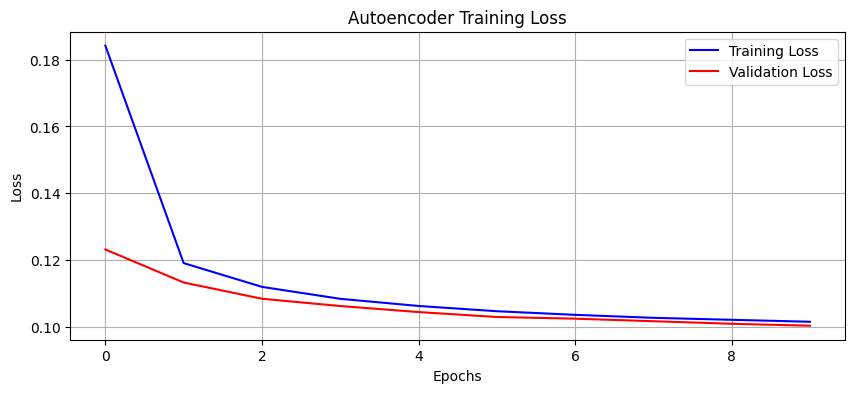

Final Training Loss: 0.1014
Final Validation Loss: 0.1002


In [6]:
# Plot Training Loss
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], 'b', label='Training Loss')
plt.plot(history.history['val_loss'], 'r', label='Validation Loss')
plt.title('Autoencoder Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

print(f"Final Training Loss: {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


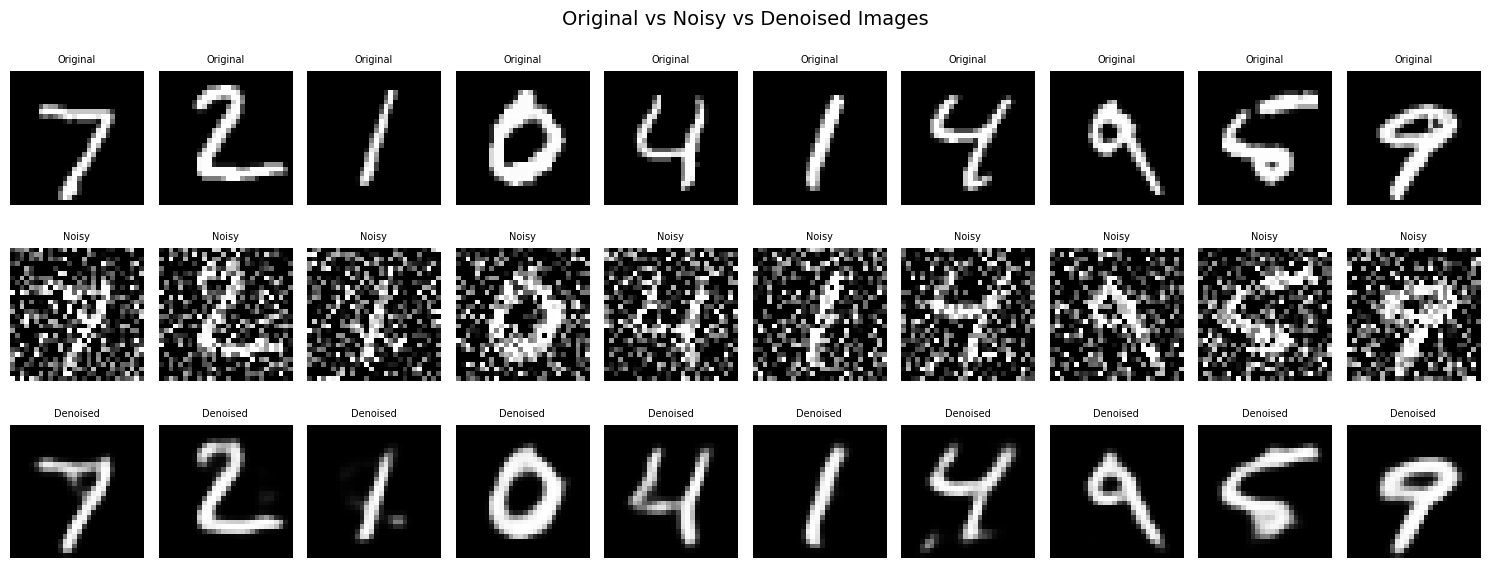

In [7]:
# Predict denoised images
denoised_images = autoencoder.predict(X_test_noisy)

# Visualize Original vs Noisy vs Denoised
plt.figure(figsize=(15, 6))
for i in range(10):
    # Original
    plt.subplot(3, 10, i+1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original", fontsize=7)
    plt.axis('off')

    # Noisy
    plt.subplot(3, 10, i+11)
    plt.imshow(X_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy", fontsize=7)
    plt.axis('off')

    # Denoised
    plt.subplot(3, 10, i+21)
    plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
    plt.title("Denoised", fontsize=7)
    plt.axis('off')

plt.suptitle("Original vs Noisy vs Denoised Images", fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
# Conclusion
print("=" * 50)
print("AUTOENCODER FOR IMAGE DENOISING - SUMMARY")
print("=" * 50)

print(f"""
Dataset: MNIST
Train samples: {X_train.shape[0]}
Test samples: {X_test.shape[0]}
Image size: 28x28x1
Noise factor: 0.5
Epochs: 10
Batch size: 128

Model Architecture:
───────────────────────────────
ENCODER:
  Conv2D(32) → MaxPooling2D
  Conv2D(16) → MaxPooling2D

DECODER:
  Conv2D(16) → UpSampling2D
  Conv2D(32) → UpSampling2D
  Conv2D(1)  → Output
───────────────────────────────

Results:
  Final Training Loss:   {history.history['loss'][-1]:.4f}
  Final Validation Loss: {history.history['val_loss'][-1]:.4f}

Observations:
1. Autoencoder successfully learned to
   remove noise from MNIST images
2. Encoder compresses image to latent space
3. Decoder reconstructs clean image
4. Loss decreased consistently over epochs
""")

AUTOENCODER FOR IMAGE DENOISING - SUMMARY

Dataset: MNIST
Train samples: 60000
Test samples: 10000
Image size: 28x28x1
Noise factor: 0.5
Epochs: 10
Batch size: 128

Model Architecture:
───────────────────────────────
ENCODER:
  Conv2D(32) → MaxPooling2D
  Conv2D(16) → MaxPooling2D

DECODER:
  Conv2D(16) → UpSampling2D
  Conv2D(32) → UpSampling2D
  Conv2D(1)  → Output
───────────────────────────────

Results:
  Final Training Loss:   0.1014
  Final Validation Loss: 0.1002

Observations:
1. Autoencoder successfully learned to
   remove noise from MNIST images
2. Encoder compresses image to latent space
3. Decoder reconstructs clean image
4. Loss decreased consistently over epochs

